# Análisis de Datos - CRM + Billing + Universidad

Pipeline que transforma datos crudos de 3 sistemas en información útil.
Las áreas se relacionan así:
- **University** (estudiantes, cursos, notas)
- **Billing** (clientes, facturas, pagos)
- **CRM** (cuentas, contactos, oportunidades)
- **Cruce**: `customers.external_ref` = `students.student_id` (estudiante se convierte en cliente)

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import os
DB_URI = f"postgresql://{os.getenv('POSTGRES_USER', 'bootcamp')}:{os.getenv('POSTGRES_PASSWORD', 'bootcamp')}@postgres:5432/{os.getenv('POSTGRES_DB', 'bootcamp')}"


## 1. Estudiantes por país (University)

In [114]:
df_students = pd.read_sql("SELECT country, COUNT(*) as total FROM gold.students GROUP BY country ORDER BY total DESC", DB_URI)
df_students

,country,total
0,CL,1980
1,AR,523
2,PE,513
3,MX,483
4,BR,427
5,ES,390
6,CO,389
7,US,295


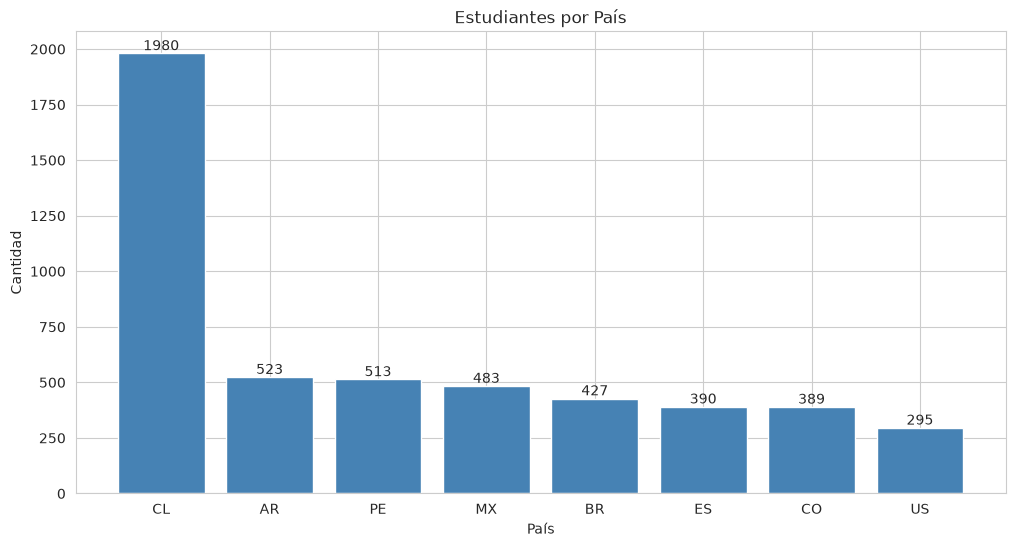

In [115]:
plt.figure()
bars = plt.bar(df_students['country'], df_students['total'], color='steelblue')
plt.title('Estudiantes por País')
plt.xlabel('País')
plt.ylabel('Cantidad')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom')
plt.show()

## 2. Ingresos mensuales (Billing)

In [116]:
df_revenue = pd.read_sql("SELECT month, total_revenue, paying_customers FROM gold.calculo_tabpagos_tabfacturas_datorecaudacion ORDER BY month", DB_URI)
df_revenue['month'] = pd.to_datetime(df_revenue['month'])
df_revenue

,month,total_revenue,paying_customers
0,2022-01-01 00:00:00+00:00,45580.40,339
1,2022-02-01 00:00:00+00:00,109348.94,744
2,2022-03-01 00:00:00+00:00,138749.93,938
3,2022-04-01 00:00:00+00:00,148101.90,933
4,2022-05-01 00:00:00+00:00,134552.47,951
5,2022-06-01 00:00:00+00:00,127288.77,921
6,2022-07-01 00:00:00+00:00,139719.96,929
7,2022-08-01 00:00:00+00:00,147291.74,915
8,2022-09-01 00:00:00+00:00,137340.74,941
9,2022-10-01 00:00:00+00:00,129348.90,942


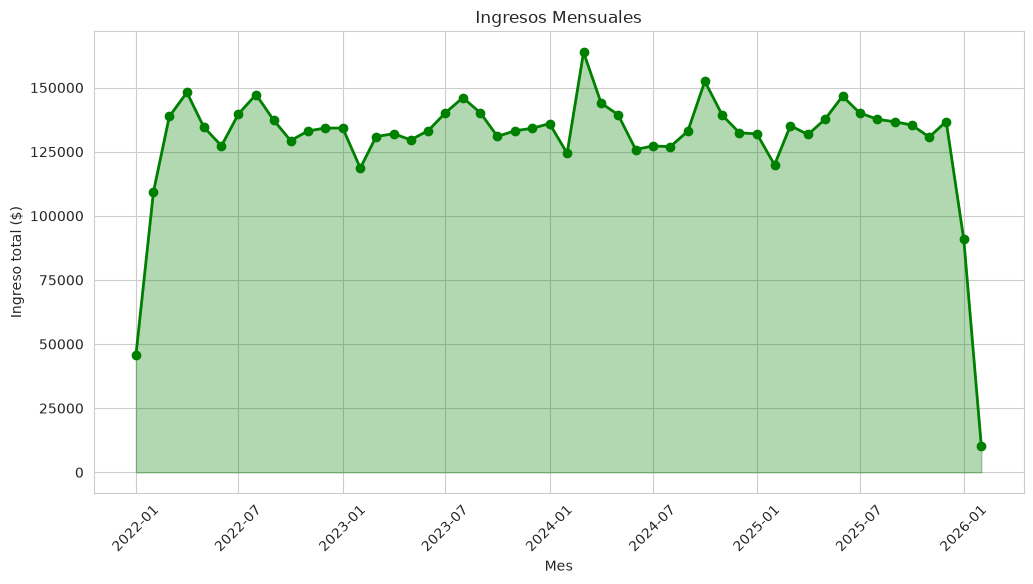

In [117]:
plt.figure()
plt.fill_between(df_revenue['month'], df_revenue['total_revenue'], alpha=0.3, color='green')
plt.plot(df_revenue['month'], df_revenue['total_revenue'], marker='o', linewidth=2, color='green')
plt.title('Ingresos Mensuales')
plt.xlabel('Mes')
plt.ylabel('Ingreso total ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 3. Pipeline de ventas (CRM)

In [118]:
df_pipeline = pd.read_sql("SELECT etapa, oportunidades, monto_total, monto_promedio FROM gold.calculo_taboportunidades_datomontoporetapa", DB_URI)
df_pipeline

,etapa,oportunidades,monto_total,monto_promedio
0,Prospeccion,621,22829672.15,36762.76
1,Calificacion,611,23040966.86,37710.26
2,Propuesta,569,22222895.05,39056.05
3,Negociacion,420,15370881.80,36597.34
4,Ganada,476,18360511.13,38572.50
5,Perdida,303,11940870.10,39408.81


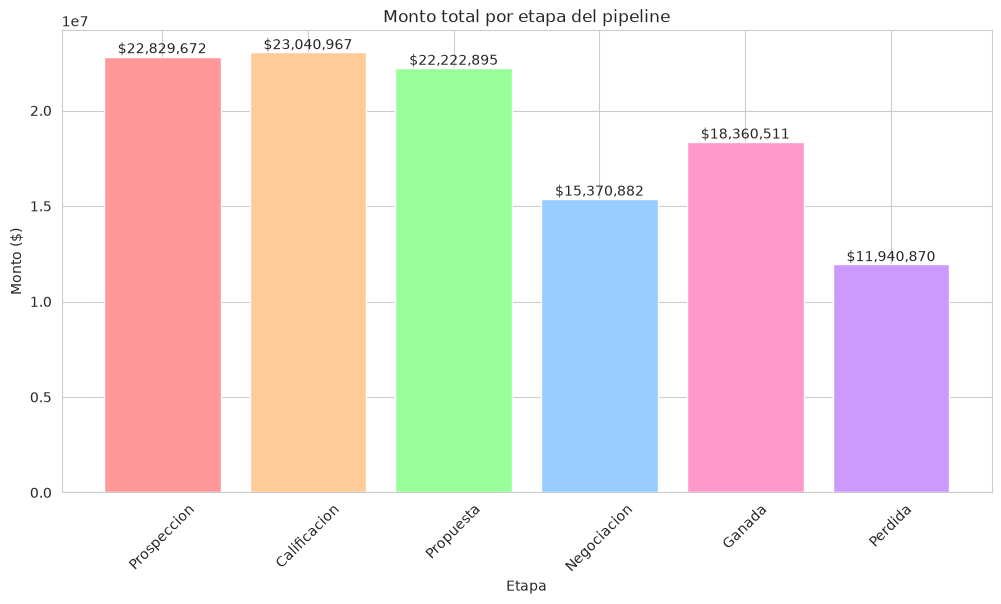

In [119]:
plt.figure()
bars = plt.bar(df_pipeline['etapa'], df_pipeline['monto_total'], color=['#ff9999','#ffcc99','#99ff99','#99ccff','#ff99cc','#cc99ff'])
plt.title('Monto total por etapa del pipeline')
plt.xlabel('Etapa')
plt.ylabel('Monto ($)')
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'${bar.get_height():,.0f}', ha='center', va='bottom')
plt.show()

## 4. Top 10 estudiantes con mejor rendimiento (University)

In [120]:
df_perf = pd.read_sql("""
    SELECT student_name, country, avg_score, total_courses
    FROM gold.calculo_tabestudiantes_tabmatriculas_tabnotas_datopromedio
    WHERE avg_score IS NOT NULL
    ORDER BY avg_score DESC
    LIMIT 10
""", DB_URI)
df_perf.index = range(1, len(df_perf) + 1)
df_perf

,student_name,country,avg_score,total_courses
1,Lucia Contreras,CL,100.00,1
2,Juan Vera,CL,95.80,1
3,Eduardo Cortes,CL,94.62,2
4,Luis Pino,CL,94.50,3
5,Matias Pizarro,CL,92.15,4
6,Antonia Araya,PE,91.73,2
7,Trinidad Vera,CL,91.46,2
8,Cristobal Bravo,MX,90.65,1
9,Magdalena Henriquez,CL,90.52,4
10,Vicente Henriquez,AR,90.51,2


## 5. Top 10 clientes que más facturan (Billing)

In [121]:
df_top = pd.read_sql("""
    SELECT c.first_name || ' ' || c.last_name AS customer,
           c.country, c.segment, SUM(i.total) AS total_billed
    FROM gold.invoices i
    JOIN gold.customers c ON i.customer_id = c.customer_id
    GROUP BY c.first_name, c.last_name, c.country, c.segment
    ORDER BY total_billed DESC
    LIMIT 10
""", DB_URI)
df_top.index = range(1, len(df_top) + 1)
df_top

,customer,country,segment,total_billed
1,Pedro Tapia,CL,retail,6716.15
2,Daniel Sandoval,CL,retail,5599.15
3,Nicolas Gutierrez,CL,retail,5492.09
4,Carlos Aravena,CL,retail,5319.25
5,Isabel Torres,CL,retail,5256.30
6,Rodrigo Bravo,CL,retail,5021.27
7,Carmen Lopez,CL,retail,4906.08
8,Nicolas Ortiz,CL,retail,4812.99
9,Daniel Gomez,CL,retail,4659.64
10,Jose Aravena,CL,retail,4659.29


## 6. Clientes con deuda pendiente (Billing)

In [122]:
df_debt = pd.read_sql("""
    SELECT c.first_name || ' ' || c.last_name AS customer,
           i.issued_at, i.total, i.balance_due
    FROM gold.invoices i
    JOIN gold.customers c ON i.customer_id = c.customer_id
    WHERE i.balance_due > 0
    ORDER BY i.balance_due DESC
    LIMIT 10
""", DB_URI)
df_debt.index = range(1, len(df_debt) + 1)
df_debt

,customer,issued_at,total,balance_due
1,Daniela Pereira,2025-01-28,4348.24,4348.24
2,Nicolas Ortiz,2025-09-22,2939.01,2939.01
3,Benjamin Diaz,2022-02-17,2458.75,2458.75
4,Luis Perez,2025-01-11,3157.51,2429.68
5,Catalina Martinez,2024-03-22,2253.06,2253.06
6,Felipe Torres,2022-09-07,2151.39,2151.39
7,Alejandro Gonzalez,2022-08-06,1920.64,1920.64
8,Benjamin Contreras,2024-07-03,1900.33,1900.33
9,Isabel Torres,2025-08-01,1878.93,1878.93
10,Juan Espinoza,2024-10-11,1831.64,1831.64


## 7. Cruce University-Billing: conversión estudiante a cliente

In [123]:
df_cross = pd.read_sql("SELECT country, total_students, became_customers, conversion_pct, avg_revenue_per_student FROM gold.calculo_tabestudiantes_tabclientes_datoconversion ORDER BY conversion_pct DESC", DB_URI)
df_cross

,country,total_students,became_customers,conversion_pct,avg_revenue_per_student
0,AR,523,523,100.0,135.26
1,BR,427,427,100.0,136.52
2,CL,1980,1980,100.0,132.99
3,CO,389,389,100.0,135.77
4,ES,390,390,100.0,133.65
5,MX,483,483,100.0,136.62
6,PE,513,513,100.0,136.33
7,US,295,295,100.0,143.41


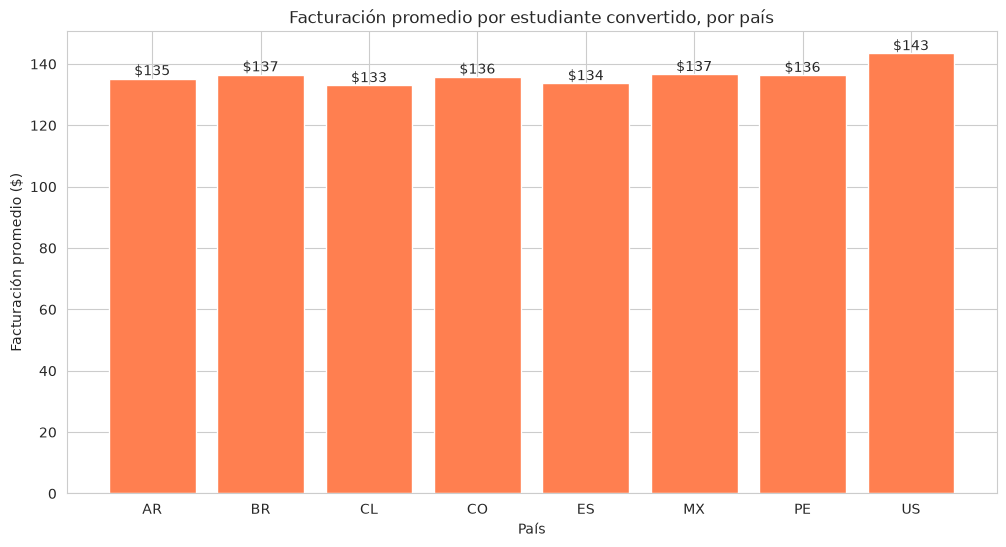

Total estudiantes: 5,000
Convertidos en clientes: 5,000 (100.0%)
Facturación promedio global por estudiante: $136.32


In [124]:
plt.figure()
bars = plt.bar(df_cross['country'], df_cross['avg_revenue_per_student'], color='coral')
plt.title('Facturación promedio por estudiante convertido, por país')
plt.xlabel('País')
plt.ylabel('Facturación promedio ($)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'${bar.get_height():,.0f}', ha='center', va='bottom')
plt.show()

total_est = df_cross['total_students'].sum()
total_conv = df_cross['became_customers'].sum()
print(f"Total estudiantes: {total_est:,}")
print(f"Convertidos en clientes: {total_conv:,} ({total_conv/total_est*100:.1f}%)")
print(f"Facturación promedio global por estudiante: ${df_cross['avg_revenue_per_student'].mean():,.2f}")

## 8. Resumen ejecutivo

**Hallazgos principales:**
- 5,000 estudiantes activos, con mayor concentración en Chile (CL)
- Ingresos mensuales estables alrededor de $130,000/mes
- Pipeline de ventas con oportunidades en distintas etapas
- Relación directa entre estudiantes y clientes: todo estudiante tiene un perfil de facturación

**Próximos pasos recomendados:**
- Analizar retención de clientes por segmento (RFM)
- Identificar estudiantes en riesgo académico (bajo promedio)
- Correlacionar rendimiento académico con facturación
- Reducir churn de suscripciones con mayor rotación
- Dar seguimiento a clientes con riesgo alto de cobranza

## 9. RFM - Segmentación de clientes (Billing)

In [125]:
df_rfm = pd.read_sql("""
    SELECT rfm_segment, COUNT(*) AS total,
           ROUND(AVG(monetary), 2) AS avg_monetary
    FROM gold.calculo_tabclientes_datorfm
    GROUP BY rfm_segment
    ORDER BY MIN(frequency) DESC
""", DB_URI)
df_rfm.index = range(1, len(df_rfm) + 1)
df_rfm

,rfm_segment,total,avg_monetary
1,Ocasional,4245,774.94
2,Perdido,5755,615.72


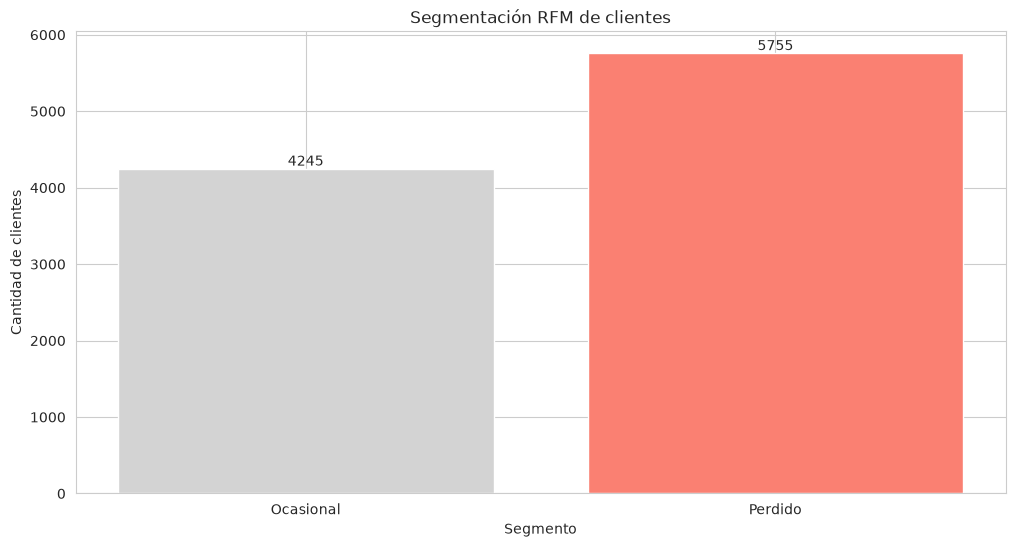

---
Ocasional: 4245 clientes, gasto promedio $774.94
Perdido: 5755 clientes, gasto promedio $615.72


In [126]:
plt.figure()
colors = {'VIP': 'gold', 'Frecuente': 'steelblue', 'Ocasional': 'lightgray', 'Perdido': 'salmon'}
bars = plt.bar(df_rfm['rfm_segment'], df_rfm['total'],
               color=[colors[s] for s in df_rfm['rfm_segment']])
plt.title('Segmentación RFM de clientes')
plt.xlabel('Segmento')
plt.ylabel('Cantidad de clientes')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             int(bar.get_height()), ha='center', va='bottom')
plt.show()

print('---')
for _, row in df_rfm.iterrows():
    print(f"{row['rfm_segment']}: {int(row['total'])} clientes, gasto promedio ${row['avg_monetary']:,.2f}")

## 10. Rendimiento por curso (University)

In [127]:
df_course = pd.read_sql("""
    SELECT course_name, department, total_students, avg_score
    FROM gold.calculo_tabcursos_tabmatriculas_tabnotas_datopromedio
    WHERE avg_score IS NOT NULL
    ORDER BY avg_score DESC
    LIMIT 10
""", DB_URI)
df_course.index = range(1, len(df_course) + 1)
df_course

,course_name,department,total_students,avg_score
1,Course 00141,cs,81,77.35
2,Course 00010,cs,104,76.95
3,Course 00084,cs,78,76.74
4,Course 00263,math,77,76.72
5,Course 00035,biology,76,76.71
6,Course 00022,literature,69,76.65
7,Course 00194,biology,88,76.64
8,Course 00126,biology,82,76.62
9,Course 00283,economics,66,76.61
10,Course 00110,cs,82,76.42


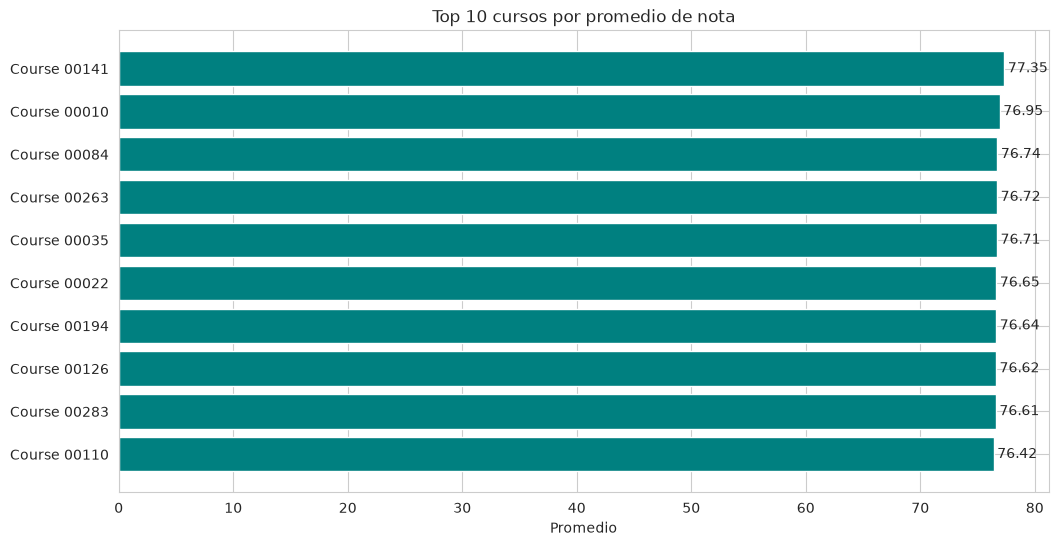


Cursos con peor rendimiento:
 course_name  avg_score  total_students
Course 00042      72.34             105
Course 00144      72.74              68
Course 00279      72.86              63
Course 00188      72.88              84
Course 00068      73.05              83


In [128]:
plt.figure()
bars = plt.barh(range(len(df_course)), df_course['avg_score'], color='teal')
plt.yticks(range(len(df_course)), df_course['course_name'])
plt.title('Top 10 cursos por promedio de nota')
plt.xlabel('Promedio')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', ha='left', va='center')
plt.show()

df_worst = pd.read_sql("""
    SELECT course_name, department, total_students, avg_score
    FROM gold.calculo_tabcursos_tabmatriculas_tabnotas_datopromedio
    WHERE avg_score IS NOT NULL
    ORDER BY avg_score ASC
    LIMIT 5
""", DB_URI)
print('\nCursos con peor rendimiento:')
print(df_worst[['course_name', 'avg_score', 'total_students']].to_string(index=False))

## 11. Carga docente por profesor (University)

In [129]:
df_prof = pd.read_sql("""
    SELECT professor_name, department, total_courses, total_students
    FROM gold.calculo_tabprofesores_tabcursos_tabmatriculas_datoalumnos
    ORDER BY total_students DESC
    LIMIT 10
""", DB_URI)
df_prof.index = range(1, len(df_prof) + 1)
df_prof

,professor_name,department,total_courses,total_students
1,Josefa Sepulveda,economics,6,508
2,Sofia Valenzuela,math,5,446
3,Valentina Castillo,literature,4,352
4,Benjamin Munoz,cs,4,339
5,Emilia Saavedra,biology,4,331
6,Sebastian Gomez,physics,4,325
7,Diego Munoz,cs,4,321
8,Fernanda Contreras,biology,4,320
9,Matias Fuentes,math,3,295
10,Manuel Tapia,literature,3,280


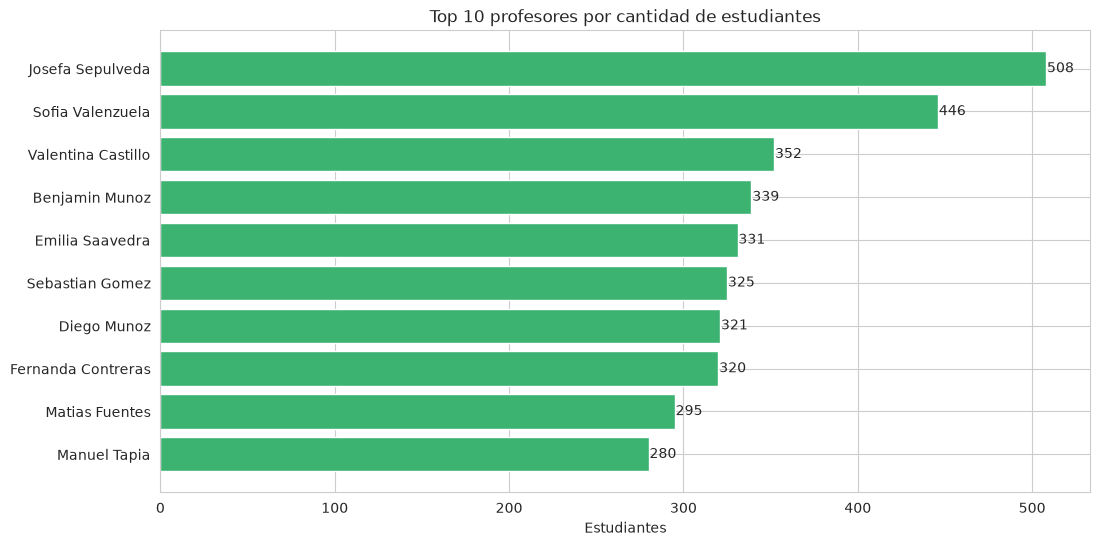

Promedio de estudiantes por profesor (top 10): 352
Total de cursos a cargo: 41


In [130]:
plt.figure()
bars = plt.barh(range(len(df_prof)), df_prof['total_students'], color='mediumseagreen')
plt.yticks(range(len(df_prof)), df_prof['professor_name'])
plt.title('Top 10 profesores por cantidad de estudiantes')
plt.xlabel('Estudiantes')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             int(bar.get_width()), ha='left', va='center')
plt.show()

avg = df_prof['total_students'].mean()
print(f'Promedio de estudiantes por profesor (top 10): {avg:.0f}')
print(f'Total de cursos a cargo: {df_prof["total_courses"].sum()}')

## 12. Churn de suscripciones (Billing)

In [131]:
df_churn = pd.read_sql("""
    SELECT product_category, product_name,
           total_subscriptions, active, cancelled, churn_rate_pct
    FROM gold.calculo_tabsuscripciones_tabproductos_datotasaabandono
    ORDER BY churn_rate_pct DESC
""", DB_URI)
df_churn.index = range(1, len(df_churn) + 1)
df_churn

,product_category,product_name,total_subscriptions,active,cancelled,churn_rate_pct
1,premium,Product 00174,68,47,18,26.5
2,basic,Product 00183,86,56,22,25.6
3,enterprise,Product 00181,78,48,18,23.1
4,standard,Product 00094,70,49,16,22.9
5,basic,Product 00049,71,50,16,22.5
...,...,...,...,...,...,...
196,basic,Product 00159,71,57,5,7.0
197,basic,Product 00079,71,59,5,7.0
198,standard,Product 00066,79,66,5,6.3
199,basic,Product 00087,80,65,5,6.3


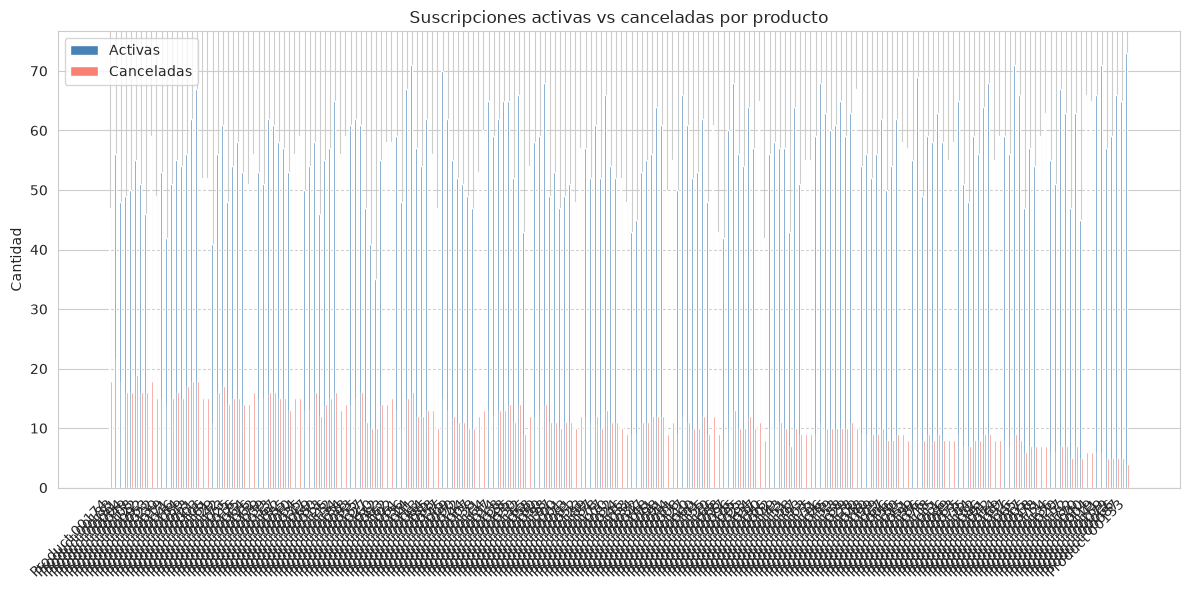


Producto con mayor churn: Product 00174 (26.5%)
Producto con menor churn: Product 00133 (4.7%)


In [132]:
plt.figure()
x = range(len(df_churn))
w = 0.35
plt.bar([i - w/2 for i in x], df_churn['active'], w, label='Activas', color='steelblue')
plt.bar([i + w/2 for i in x], df_churn['cancelled'], w, label='Canceladas', color='salmon')
plt.xticks(x, df_churn['product_name'], rotation=45, ha='right')
plt.title('Suscripciones activas vs canceladas por producto')
plt.ylabel('Cantidad')
plt.legend()
plt.tight_layout()
plt.show()

worst = df_churn.loc[df_churn['churn_rate_pct'].idxmax()]
print(f'\nProducto con mayor churn: {worst["product_name"]} ({worst["churn_rate_pct"]}%)')
print(f'Producto con menor churn: {df_churn.loc[df_churn["churn_rate_pct"].idxmin()]["product_name"]} ({df_churn["churn_rate_pct"].min()}%)')

## 13. Ciclo de vida estudiante → cliente (Cruce)

In [133]:
df_life = pd.read_sql("""
    SELECT student_country,
           COUNT(*) AS total,
           ROUND(AVG(days_to_first_invoice)) AS avg_days_to_invoice,
           ROUND(AVG(total_billed), 2) AS avg_billed
    FROM gold.calculo_tabestudiantes_tabclientes_datociclovida
    WHERE days_to_first_invoice IS NOT NULL
    GROUP BY student_country
    ORDER BY avg_days_to_invoice
""", DB_URI)
df_life.index = range(1, len(df_life) + 1)
df_life

,student_country,total,avg_days_to_invoice,avg_billed
1,PE,510,248.0,699.58
2,CO,386,287.0,678.14
3,ES,389,308.0,668.93
4,CL,1970,344.0,673.95
5,BR,425,344.0,675.52
6,US,292,351.0,724.93
7,MX,476,358.0,674.78
8,AR,519,371.0,694.81


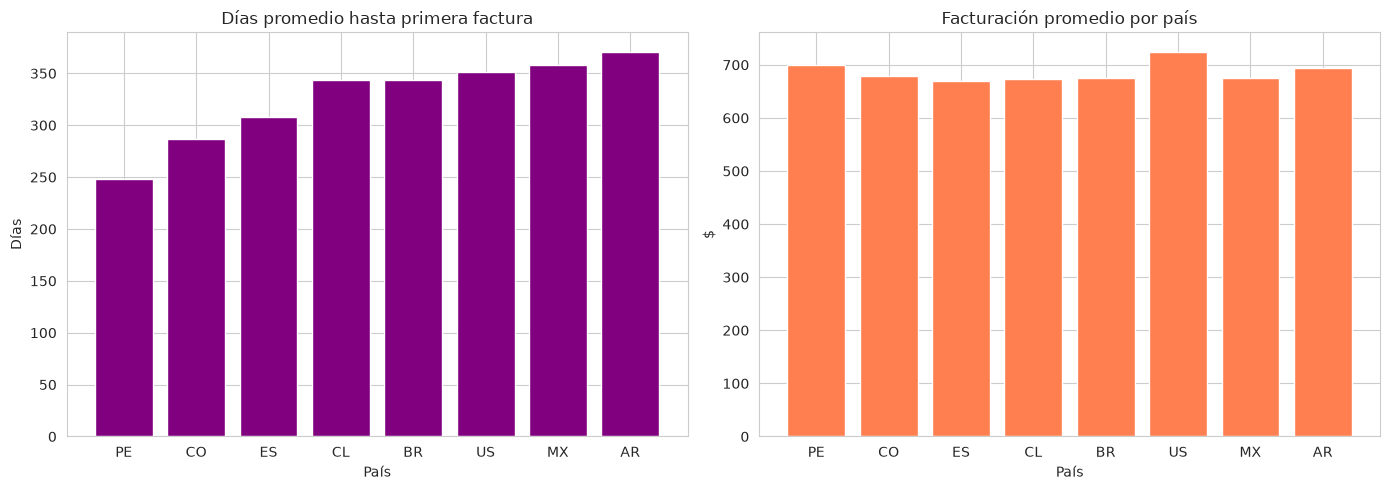

Promedio global días a primera factura: 326 días
País más rápido: PE (248 días)
País más lento: AR (371 días)


In [134]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(df_life['student_country'], df_life['avg_days_to_invoice'], color='purple')
ax1.set_title('Días promedio hasta primera factura')
ax1.set_xlabel('País')
ax1.set_ylabel('Días')

ax2.bar(df_life['student_country'], df_life['avg_billed'], color='coral')
ax2.set_title('Facturación promedio por país')
ax2.set_xlabel('País')
ax2.set_ylabel('$')

plt.tight_layout()
plt.show()

print(f'Promedio global días a primera factura: {df_life["avg_days_to_invoice"].mean():.0f} días')
print(f'País más rápido: {df_life.loc[df_life["avg_days_to_invoice"].idxmin(), "student_country"]} ({df_life["avg_days_to_invoice"].min():.0f} días)')
print(f'País más lento: {df_life.loc[df_life["avg_days_to_invoice"].idxmax(), "student_country"]} ({df_life["avg_days_to_invoice"].max():.0f} días)')

## 14. Riesgo de cobranza (Billing)

In [135]:
df_risk = pd.read_sql("""
    SELECT risk_level, COUNT(*) AS total_customers,
           ROUND(SUM(total_debt), 2) AS total_debt_sum
    FROM gold.calculo_tabclientes_tabfacturas_datoriesgo
    GROUP BY risk_level
    ORDER BY MIN(CASE risk_level
        WHEN 'Alto' THEN 1 WHEN 'Medio' THEN 2
        WHEN 'Bajo' THEN 3 ELSE 4 END)
""", DB_URI)
df_risk.index = range(1, len(df_risk) + 1)
df_risk

,risk_level,total_customers,total_debt_sum
1,Medio,179,244923.39
2,Bajo,5599,1490950.44
3,Sin deuda,4155,-1437708.41


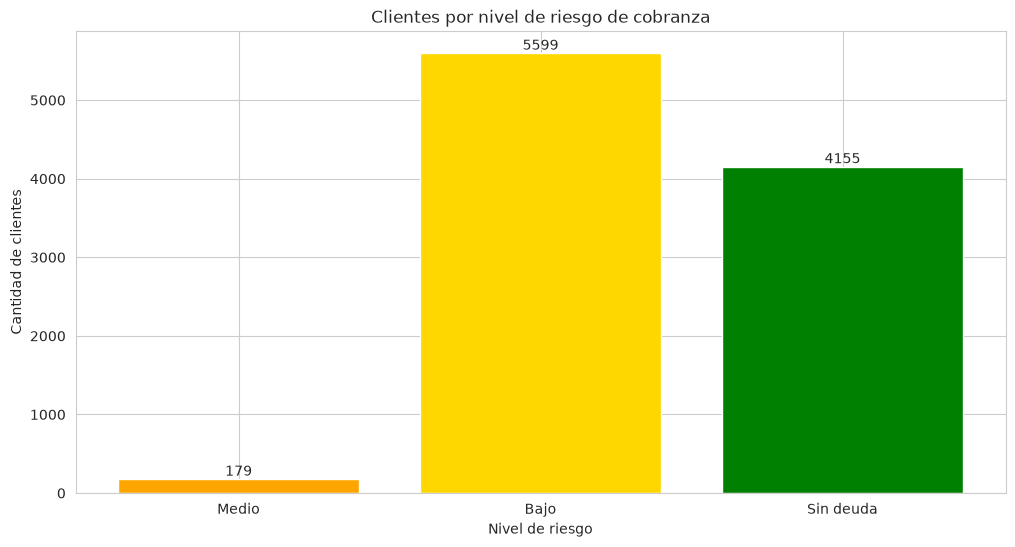

---
Medio: 179 clientes, deuda total $244,923.39
Bajo: 5599 clientes, deuda total $1,490,950.44
Sin deuda: 4155 clientes, deuda total $-1,437,708.41

Top 5 deudores de alto riesgo:
Empty DataFrame
Columns: [customer_name, total_debt, debt_ratio_pct]
Index: []


In [136]:
plt.figure()
risk_colors = {'Alto': 'red', 'Medio': 'orange', 'Bajo': 'gold', 'Sin deuda': 'green'}
bars = plt.bar(df_risk['risk_level'], df_risk['total_customers'],
               color=[risk_colors[s] for s in df_risk['risk_level']])
plt.title('Clientes por nivel de riesgo de cobranza')
plt.xlabel('Nivel de riesgo')
plt.ylabel('Cantidad de clientes')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             int(bar.get_height()), ha='center', va='bottom')
plt.show()

print('---')
for _, row in df_risk.iterrows():
    print(f"{row['risk_level']}: {int(row['total_customers'])} clientes, deuda total ${row['total_debt_sum']:,.2f}")

df_top_risk = pd.read_sql("""
    SELECT customer_name, total_debt, debt_ratio_pct
    FROM gold.calculo_tabclientes_tabfacturas_datoriesgo
    WHERE risk_level = 'Alto'
    ORDER BY total_debt DESC
    LIMIT 5
""", DB_URI)
print('\nTop 5 deudores de alto riesgo:')
print(df_top_risk.to_string(index=False))

## 15. Tasa de aprobacion por curso (University)

In [137]:
df_pass = pd.read_sql("""
    SELECT code, course_name, department, total_students,
           avg_score, pass_rate_pct, fail_rate_pct
    FROM gold.calculo_tabcursos_tabmatriculas_tabnotas_datoaprobacion
    ORDER BY pass_rate_pct ASC
    LIMIT 10
""", DB_URI)
df_pass.index = range(1, len(df_pass) + 1)
print('Peores 10 cursos por tasa de aprobacion:')
df_pass

Peores 10 cursos por tasa de aprobacion:


,code,course_name,department,total_students,avg_score,pass_rate_pct,fail_rate_pct
1,C-00248,Course 00248,economics,70,74.47,93.9,6.1
2,C-00024,Course 00024,literature,66,73.08,94.5,5.5
3,C-00153,Course 00153,literature,82,73.99,94.5,5.5
4,C-00029,Course 00029,physics,88,73.87,94.7,5.3
5,C-00142,Course 00142,biology,71,74.03,94.9,5.1
6,C-00158,Course 00158,literature,75,73.40,94.9,5.1
7,C-00091,Course 00091,physics,76,73.63,95.1,4.9
8,C-00274,Course 00274,history,80,74.09,95.2,4.8
9,C-00036,Course 00036,literature,93,74.88,95.3,4.7
10,C-00009,Course 00009,physics,70,74.90,95.3,4.7


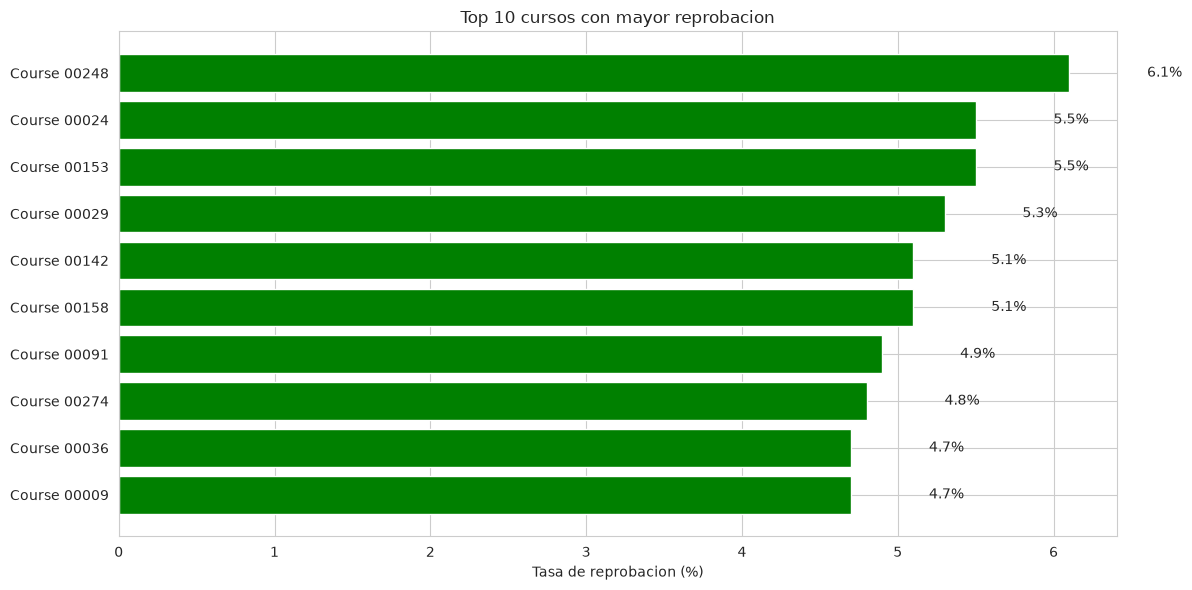

In [138]:
plt.figure()
colors = ['red' if r > 50 else 'green' for r in df_pass['fail_rate_pct']]
bars = plt.barh(df_pass['course_name'], df_pass['fail_rate_pct'], color=colors)
plt.xlabel('Tasa de reprobacion (%)')
plt.title('Top 10 cursos con mayor reprobacion')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va='center')
plt.tight_layout()
plt.show()

## 16. Matriculas por semestre (University)

In [139]:
df_enroll = pd.read_sql("""
    SELECT semester_name, start_date, total_enrollments,
           total_students, total_courses
    FROM gold.calculo_tabsemestres_tabmatriculas_datoinscripciones
    ORDER BY start_date
""", DB_URI)
df_enroll.index = range(1, len(df_enroll) + 1)
df_enroll

,semester_name,start_date,total_enrollments,total_students,total_courses
1,2022-1,2022-03-01,3164,2346,300
2,2022-2,2022-08-01,3199,2365,300
3,2023-1,2023-03-01,3143,2309,300
4,2023-2,2023-08-01,3014,2246,300
5,2024-1,2024-03-01,3076,2287,300
6,2024-2,2024-08-01,3108,2333,300
7,2025-1,2025-03-01,3110,2336,300
8,2025-2,2025-08-01,3186,2357,300


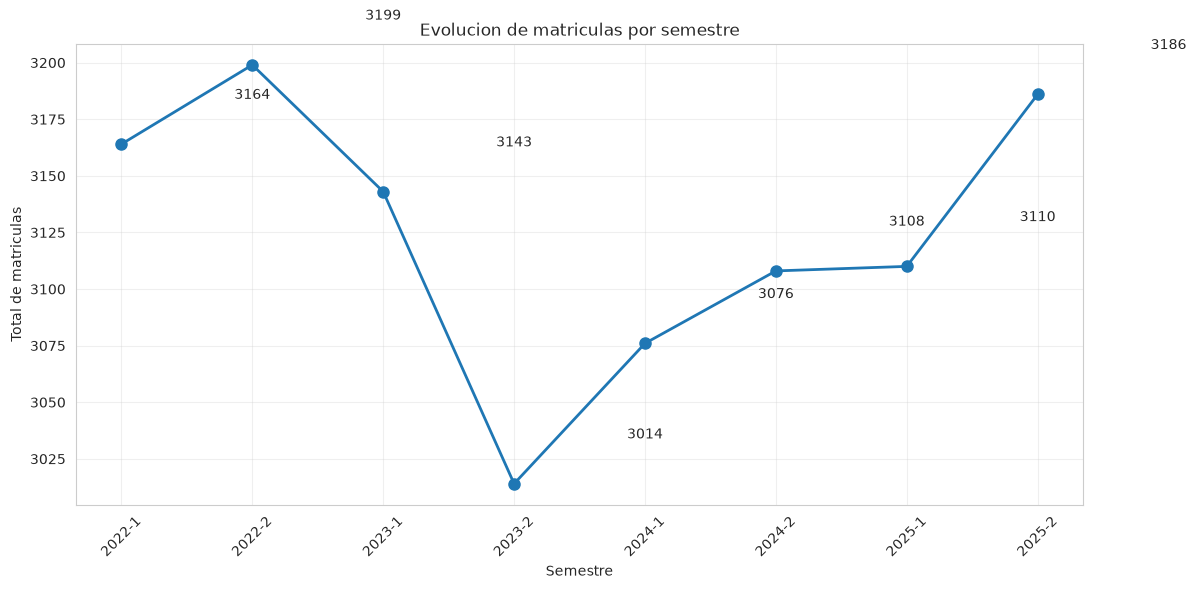

In [140]:
plt.figure()
plt.plot(df_enroll['semester_name'], df_enroll['total_enrollments'],
         marker='o', linewidth=2, markersize=8)
plt.title('Evolucion de matriculas por semestre')
plt.xlabel('Semestre')
plt.ylabel('Total de matriculas')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
for i, row in df_enroll.iterrows():
    plt.text(i, row['total_enrollments'] + 20,
             str(int(row['total_enrollments'])), ha='center')
plt.tight_layout()
plt.show()